### Handwritten Digit Recognition Program

In [7]:
import numpy as np 
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [9]:
(X_train, Y_train) , (x_test, y_test) = mnist.load_data()

In [ ]:
len(X_train)

60000

In [12]:
len(x_test)

10000

In [14]:
print("first element of x: " , X_train[0])

first element of x:  [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
  175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
  225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
   93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 2

In [17]:
print("First element of y is: ", Y_train[0])

First element of y is:  5


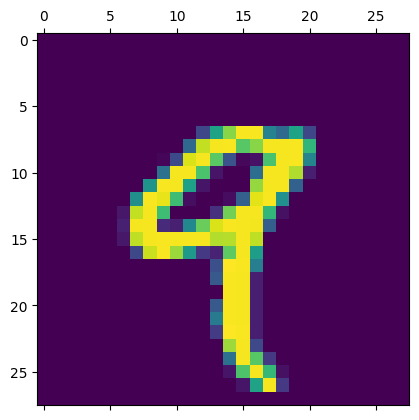

In [18]:
plt.matshow(X_train[4])

In [19]:
X_train.shape

(60000, 28, 28)

In [23]:
# FLattening 28 * 28 grid of pixels has to be flattened for processing in FC Layers
X_train_FLattened = X_train.reshape(len(X_train), 28 * 28)
x_test_FLattened = x_test.reshape(len(x_test), 28 * 28)

print(x_test_FLattened.shape)

print(X_train_FLattened.shape)

(10000, 784)
(60000, 784)


#### results arent great because our values have not been scaled

In [27]:
# Defining a model

model = Sequential(
    {
        Dense(10, input_shape = (784,), activation= 'sigmoid')
    }
)

model.compile(
    optimizer = "adam",
    loss = "sparse_categorical_crossentropy",
    metrics = ["accuracy"]
)

model.fit(X_train_FLattened, Y_train, epochs  = 5)

d:\Study_Resources\Machine Learning Specialization\Coursera\Coursera_Machine_Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.5305 - loss: 9.5450   
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 935us/step - accuracy: 0.5153 - loss: 6.1627
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 946us/step - accuracy: 0.5018 - loss: 5.7979
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.4790 - loss: 5.5064
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 939us/step - accuracy: 0.4676 - loss: 5.3789


In [28]:
X_train = X_train/255
x_test = x_test/ 255

In [ ]:
# FLattening 28 * 28 grid of pixels has to be flattened for processing in FC Layers
X_train_FLattened = X_train.reshape(len(X_train), 28 * 28)
x_test_FLattened = x_test.reshape(len(x_test), 28 * 28)

print(x_test_FLattened.shape)

print(X_train_FLattened.shape)

(10000, 784)
(60000, 784)


#### Results have improved quite a lot 

In [60]:
# Defining a model
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer="adam",
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
model = Sequential(
    [
        Dense(25, input_shape = (784,), activation= 'relu'),
        Dense(15, activation= 'relu'),
        Dense(10 , activation= 'linear')
    ]
)

model.compile(
    optimizer = "adam",
    loss = SparseCategoricalCrossentropy(from_logits = True),
    metrics = ["accuracy"]
)

model.fit(X_train_FLattened, Y_train, epochs  = 10)

logits = model(X_train_FLattened)
f_x = tf.nn.softmax(logits)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8835 - loss: 0.3910
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9452 - loss: 0.1866
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9549 - loss: 0.1539
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9596 - loss: 0.1341
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9647 - loss: 0.1203
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9661 - loss: 0.1100
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9693 - loss: 0.1020
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9717 - loss: 0.0940
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9732 - loss: 0.0875
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9755 - loss: 0.0825


In [62]:
model.evaluate(x_test_FLattened, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9620 - loss: 0.1316


[0.13161782920360565, 0.9620000123977661]

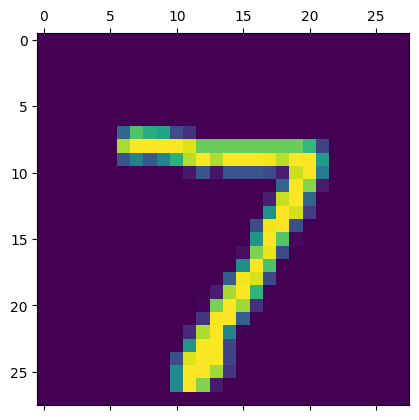

In [63]:
plt.matshow(x_test[0])

In [64]:
y_hat = model.predict(x_test_FLattened)
print(y_hat[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 695us/step
[-14.0580635 -11.991869   -0.6779472   2.244146  -20.417711   -3.9219341
 -37.800743    9.93888    -8.327743   -6.00868  ]


In [65]:
np.argmax(y_hat[0])

np.int64(7)

In [66]:
y_predicted_labels = [np.argmax(i) for i in y_hat]

In [67]:
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [68]:
cm = tf.math.confusion_matrix(labels = y_test, predictions= y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 970,    0,    1,    4,    1,    2,    0,    1,    1,    0],
       [   0, 1126,    3,    1,    0,    1,    2,    1,    1,    0],
       [   7,    4,  998,    7,    2,    0,    1,    9,    2,    2],
       [   1,    2,   14,  971,    0,    7,    0,    9,    4,    2],
       [   2,    0,    2,    1,  923,    5,    8,    4,    2,   35],
       [   6,    0,    0,   15,    1,  859,    3,    1,    5,    2],
       [  12,    3,    3,    3,    4,   11,  920,    0,    2,    0],
       [   1,    3,   15,   11,    0,    0,    0,  984,    1,   13],
       [   8,    2,    5,   27,    3,   16,    3,    4,  901,    5],
       [   6,    4,    0,   12,    5,    4,    0,    7,    3,  968]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

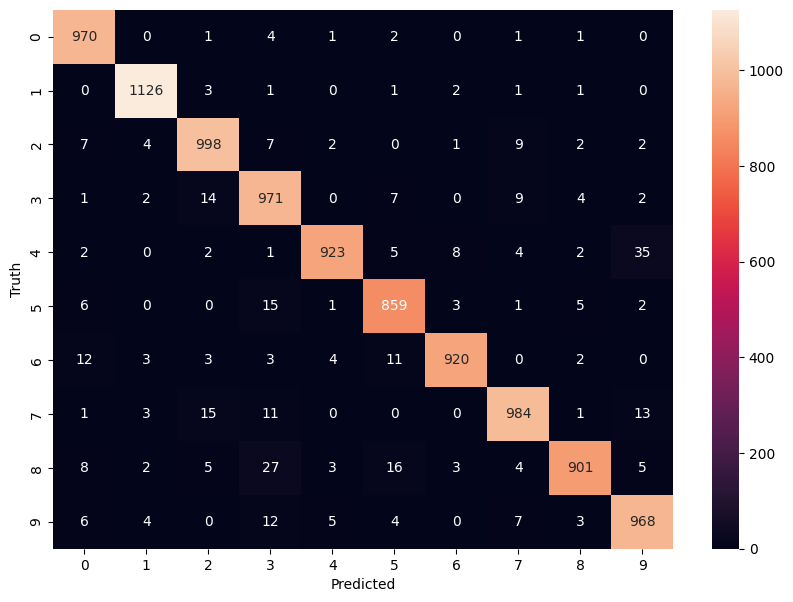

In [69]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm , annot= True, fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')